<a href="https://colab.research.google.com/github/MaggieHDez/ClassFiles/blob/main/ajuste_de_modelos_ARIMA_255879.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121

Serie temporal
Month
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
Freq: MS, Name: Passengers, dtype: int64
Tamaño de la serie: 144


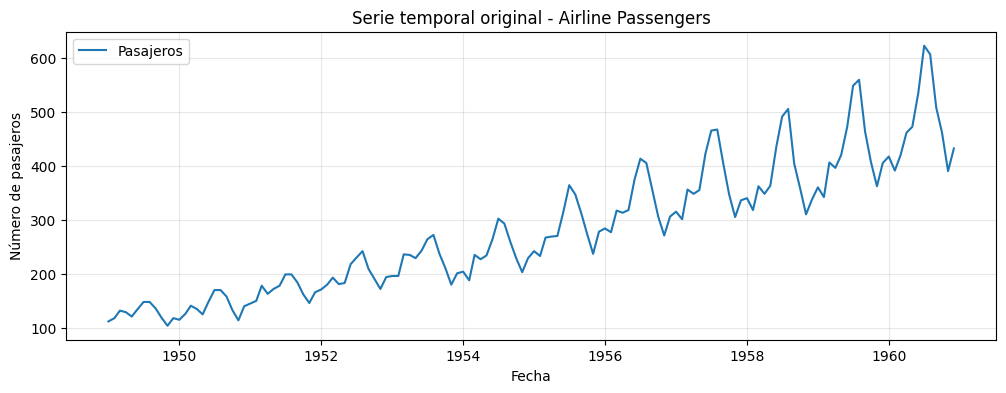

------------------------------------
Pruebas de estacionariedad para la serie original
===>Test: ADF
H0: Serie NO estacionaria
H1: Serie estacionaria
p-value: 0.991880
NO se rechaza H0
No hay evidencia suficiente contra: Serie NO estacionaria

===>Test: KPSS
H0: Serie estacionaria
H1: Serie NO estacionaria
p-value: 0.010000
Se RECHAZA H0
Evidencia a favor de: Serie NO estacionaria

------------------------------------
Serie diferenciada


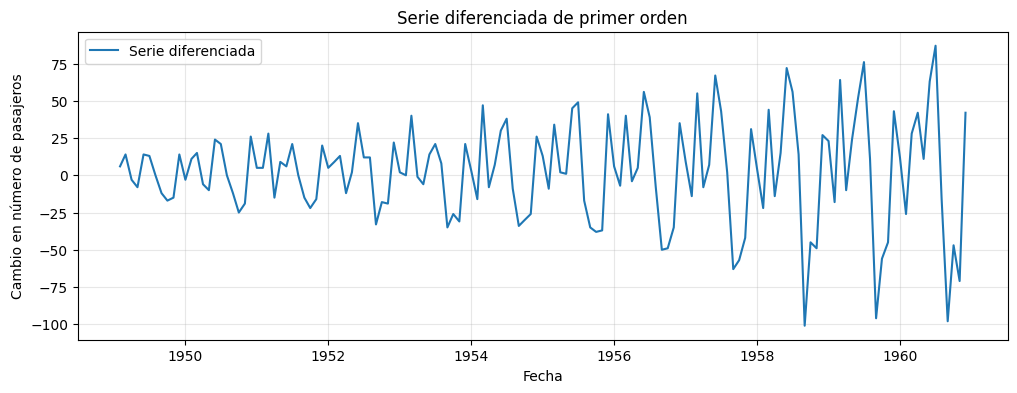

Pruebas de estacionariedad para la serie diferenciada
===>Test: ADF
H0: Serie NO estacionaria
H1: Serie estacionaria
p-value: 0.054213
NO se rechaza H0
No hay evidencia suficiente contra: Serie NO estacionaria

===>Test: KPSS
H0: Serie estacionaria
H1: Serie NO estacionaria
p-value: 0.100000
NO se rechaza H0
No hay evidencia suficiente contra: Serie estacionaria

------------------------------------


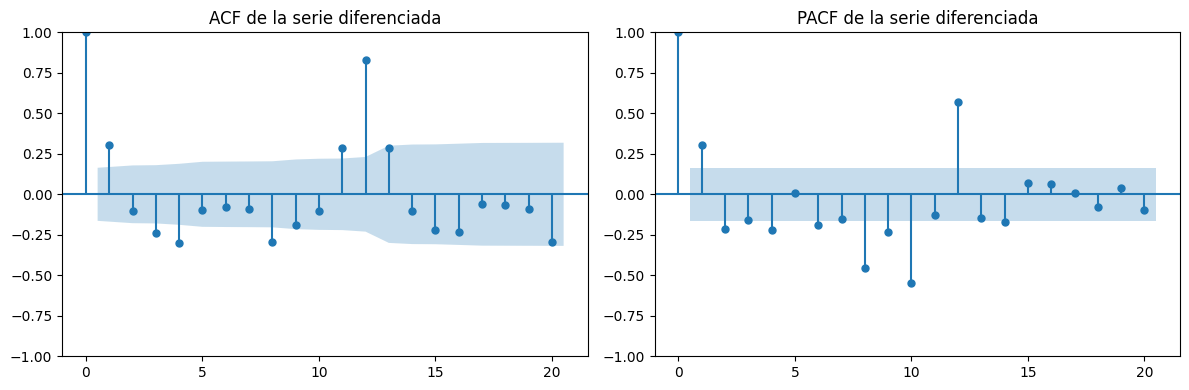

ACF:
Lag 0: 1.0000
Lag 1: 0.3029
Lag 2: -0.1021
Lag 3: -0.2413
Lag 4: -0.3004
Lag 5: -0.0941
Lag 6: -0.0784
Lag 7: -0.0924
Lag 8: -0.2948
Lag 9: -0.1918
Lag 10: -0.1049
Lag 11: 0.2829
Lag 12: 0.8292
Lag 13: 0.2845
Lag 14: -0.1058
Lag 15: -0.2221
Lag 16: -0.2311
Lag 17: -0.0623
Lag 18: -0.0662
Lag 19: -0.0904
Lag 20: -0.2971
PACF:
Lag 0: 1.0000
Lag 1: 0.3029
Lag 2: -0.2134
Lag 3: -0.1604
Lag 4: -0.2216
Lag 5: 0.0101
Lag 6: -0.1906
Lag 7: -0.1537
Lag 8: -0.4547
Lag 9: -0.2338
Lag 10: -0.5473
Lag 11: -0.1300
Lag 12: 0.5713
Lag 13: -0.1493
Lag 14: -0.1718
Lag 15: 0.0672
Lag 16: 0.0625
Lag 17: 0.0076
Lag 18: -0.0799
Lag 19: 0.0371
Lag 20: -0.0947
------------------------------------
Tamaño train: 115
Tamaño test: 29
Inicio train: 1949-01-01 00:00:00  Fin train: 1958-07-01 00:00:00
Inicio test: 1958-08-01 00:00:00  Fin test: 1960-12-01 00:00:00
------------------------------------
Modelos ordenados por AIC y BIC (más bajo es mejor):
                     Modelo          AIC          BIC
0   S

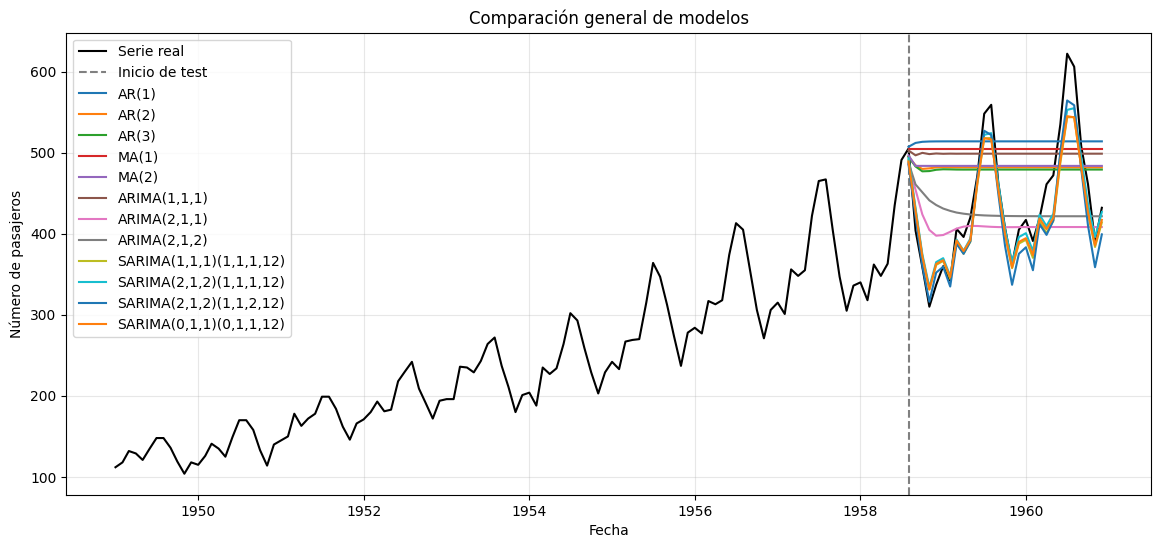

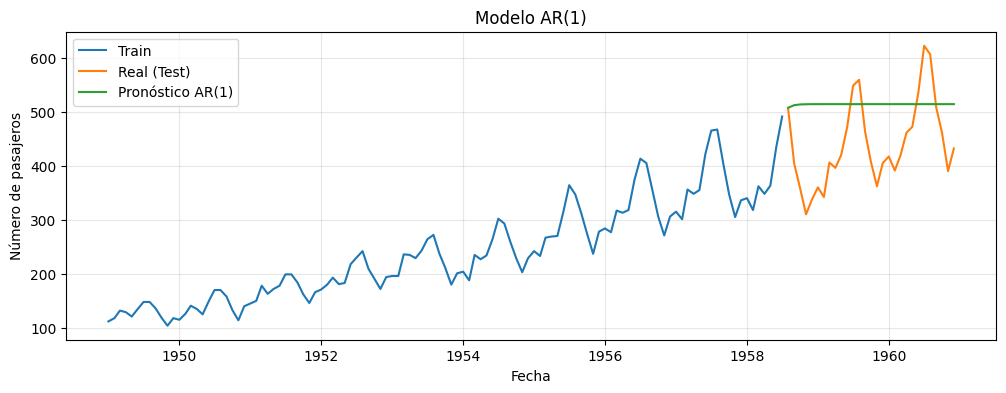

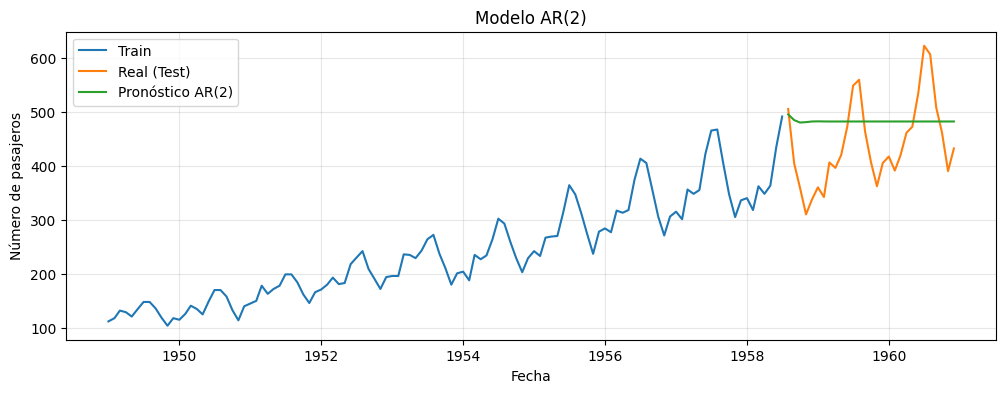

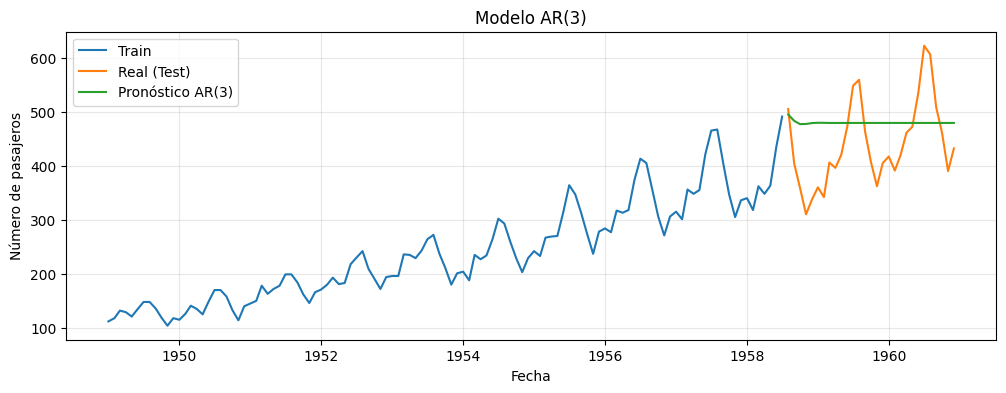

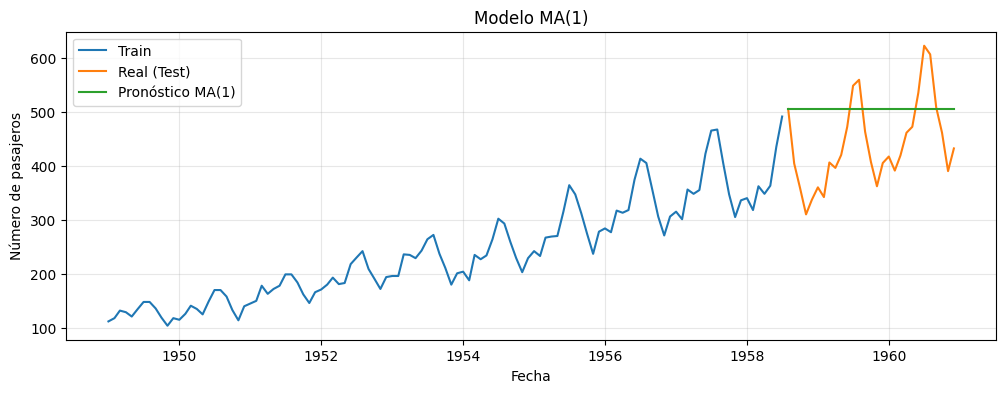

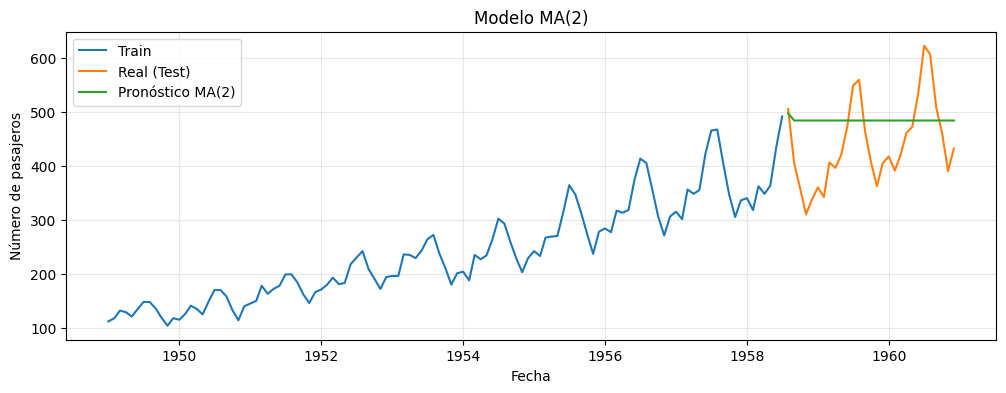

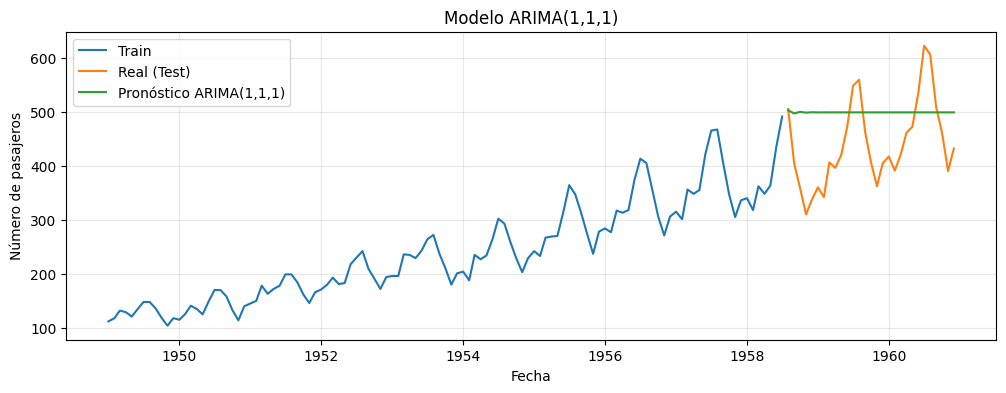

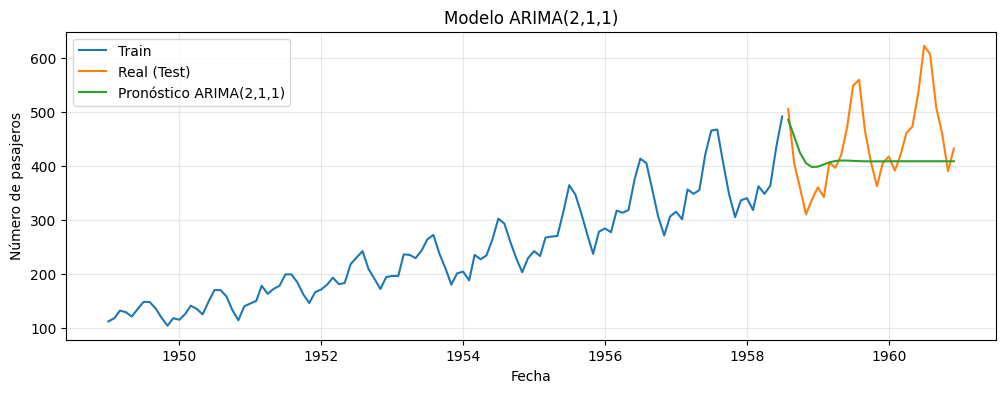

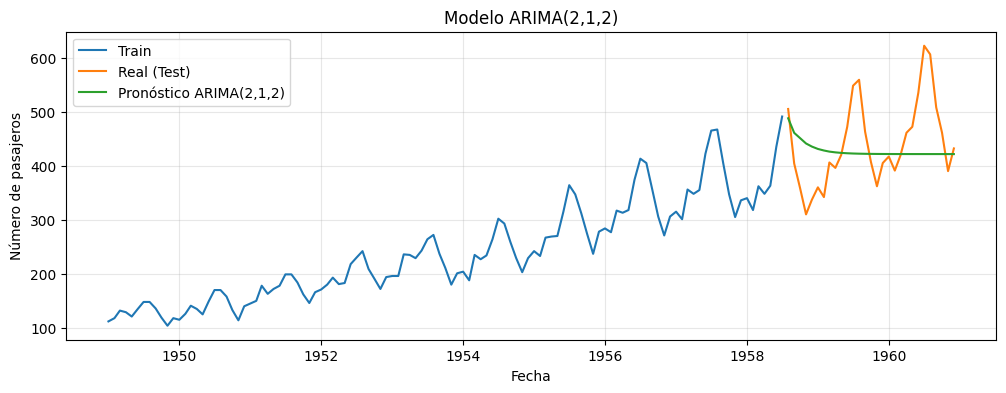

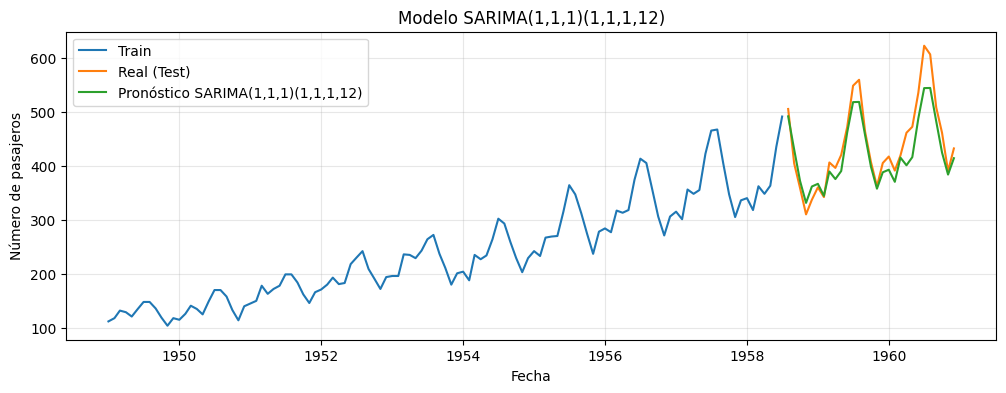

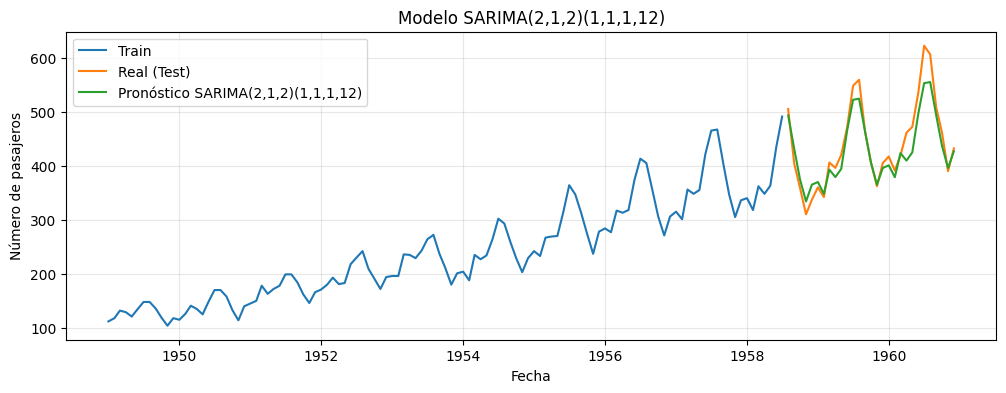

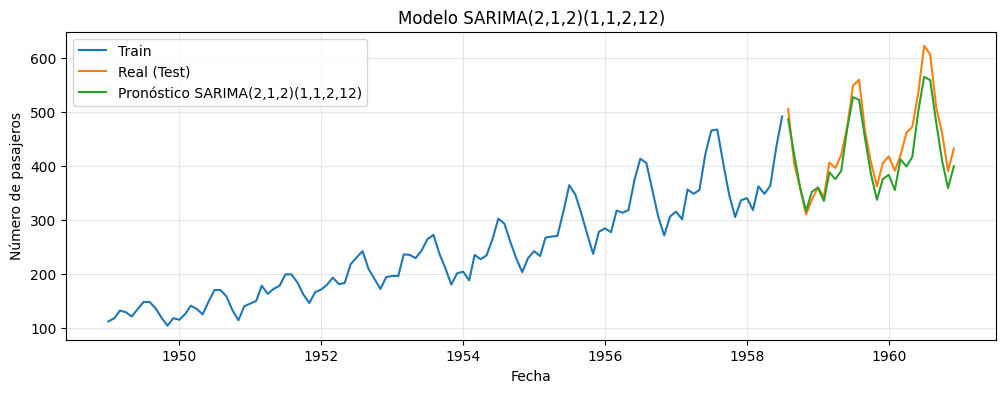

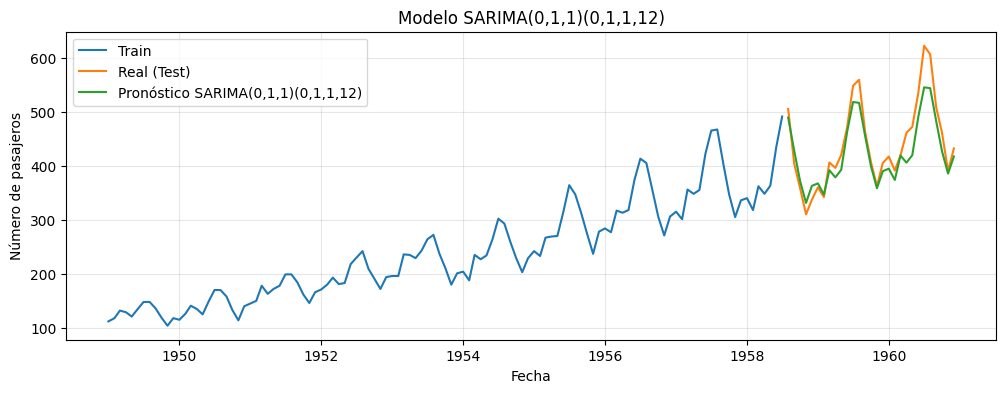

Mejor modelo por AIC/BIC para análisis de residuos: SARIMA(2,1,2)(1,1,2,12)


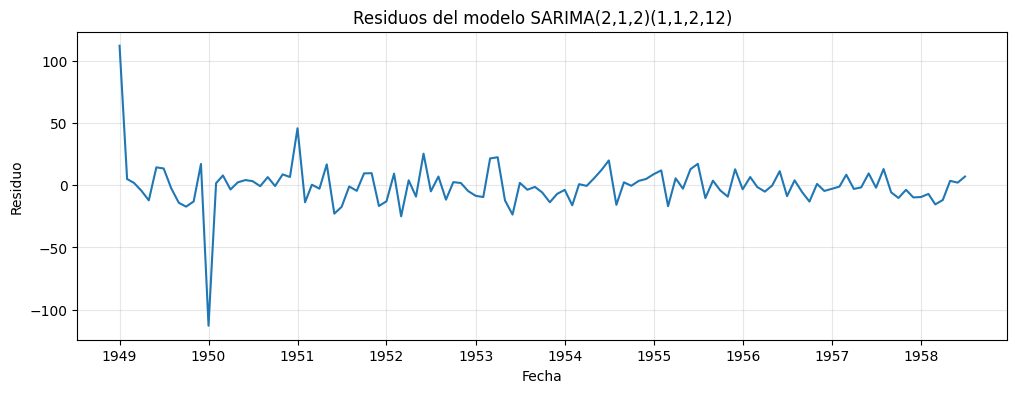

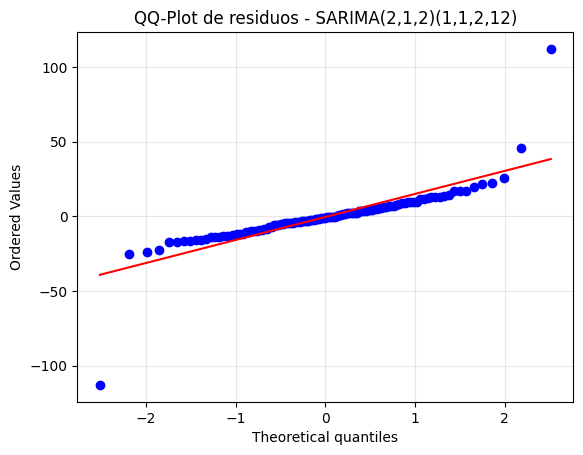

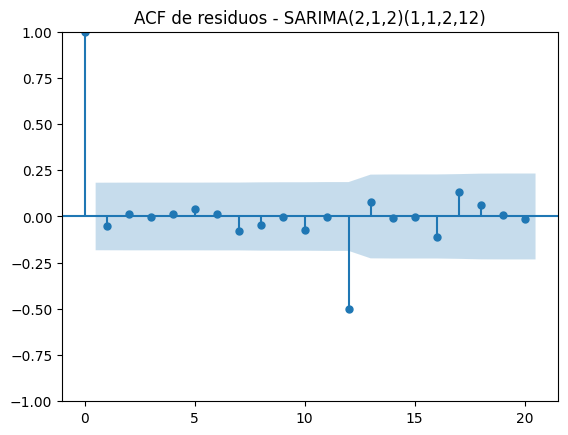

===>Test: Ljung-Box
H0: Ruido blanco
H1: Autocorrelación
p-value: 0.993059
NO se rechaza H0
No hay evidencia suficiente contra: Ruido blanco

===>Test: Jarque-Bera
H0: Normalidad
H1: No normalidad
p-value: 0.000000
Se RECHAZA H0
Evidencia a favor de: No normalidad

===>Test: ARCH (AutoRegressive Conditional Heteroskedasticity)
H0: Homocedasticidad
H1: Heterocedasticidad
p-value: 0.999999
NO se rechaza H0
No hay evidencia suficiente contra: Homocedasticidad

------------------------------------
Iniciando GridSearch para modelos ARIMA...
          Modelo      order          AIC          BIC
0   ARIMA(3,1,3)  (3, 1, 3)  1028.860718  1048.014107
1   ARIMA(3,1,2)  (3, 1, 2)  1053.343851  1069.761041
2   ARIMA(2,1,3)  (2, 1, 3)  1056.580497  1072.997688
3   ARIMA(1,1,2)  (1, 1, 2)  1057.327535  1068.272329
4   ARIMA(2,1,2)  (2, 1, 2)  1057.516178  1071.197170
5   ARIMA(1,1,1)  (1, 1, 1)  1058.245574  1066.454169
6   ARIMA(2,1,1)  (2, 1, 1)  1058.647616  1069.592409
7   ARIMA(1,1,3)  (1, 1, 3

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX # modelo nuevo

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import jarque_bera
import scipy.stats as stats

import warnings
warnings.filterwarnings("ignore")


DEBUG_SHOW_GRAPH = True
DEBUG_SHOW_GRAPH_CORRELOGRAM = True
DEBUG_SHOW_GRAPH_RESIDUALS = True


# Test estadísticos
def interpretar_test(nombre, pvalue, alpha, H0, H1):
    print(f"===>Test: {nombre}")
    print(f"H0: {H0}")
    print(f"H1: {H1}")
    print(f"p-value: {pvalue:.6f}")

    if pvalue < alpha:
        print("Se RECHAZA H0")
        print(f"Evidencia a favor de: {H1}")
    else:
        print("NO se rechaza H0")
        print(f"No hay evidencia suficiente contra: {H0}")

    print("")




#Dickey-fuller
def adf_test(series):
    result = adfuller(series.dropna())
    interpretar_test(
        "ADF",
        result[1],
        0.05,
        "Serie NO estacionaria",
        "Serie estacionaria"
    )

#KPSS
def kpss_test(series):
    result = kpss(series.dropna(), regression='c', nlags='auto')
    interpretar_test(
        "KPSS",
        result[1],
        0.05,
        "Serie estacionaria",
        "Serie NO estacionaria"
    )


# Para las leyendas de las gráficas
def obtener_orden_modelo(name, model):
    return name # solo es necesario regresar el nombre




# Métricas de evaluación de los pronósticos
def metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))
    return mae, mse, rmse, mape, smape


# =====================================
#                 MAIN
# =====================================

if __name__ == "__main__":
    # Reemplazamos la generación de datos artificiales
    # por la lectura del dataset
    df = pd.read_csv("/content/drive/MyDrive/ClassFiles/Metodos_de_Pronostico/airline-passengers.csv")

    # Conversion de la columna Month a datetime
    df["Month"] = pd.to_datetime(df["Month"])

    # Definición de Month como índice
    df.set_index("Month", inplace=True)

    # Asignación a frecuencia mensual
    df = df.asfreq("MS")

    # Creacion de serie temporal con la columna Passengers
    ts = df["Passengers"]

    # Impresion de primeros registros
    print(df.head())
    print("\nSerie temporal")
    print(ts.head())
    # Tamaño de la serie
    n = len(ts)
    print(f"Tamaño de la serie: {n}")


    # Visualización de los datos
    if DEBUG_SHOW_GRAPH:
      plt.figure(figsize=(12, 4))
      plt.plot(ts, label="Pasajeros")
      plt.title("Serie temporal original - Airline Passengers")
      plt.xlabel("Fecha")
      plt.ylabel("Número de pasajeros")
      plt.legend()
      plt.grid(alpha=0.3)
      plt.show()




    #Prueba de estacionariedad
    print("------------------------------------")
    print("Pruebas de estacionariedad para la serie original")
    adf_test(ts)
    kpss_test(ts)



    # Diferenciación de la serie para transformarla a estacionaria
    print("------------------------------------")
    print("Serie diferenciada")
    ts_diff = ts.diff().dropna()

    if DEBUG_SHOW_GRAPH:
        plt.figure(figsize=(12, 4))
        plt.plot(ts_diff, label="Serie diferenciada")
        plt.title("Serie diferenciada de primer orden")
        plt.xlabel("Fecha")
        plt.ylabel("Cambio en número de pasajeros")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

    print("Pruebas de estacionariedad para la serie diferenciada")
    adf_test(ts_diff)
    kpss_test(ts_diff)
    print("------------------------------------")




    # ACF y PACF sobre la serie diferenciada
    if DEBUG_SHOW_GRAPH_CORRELOGRAM:
        fig, ax = plt.subplots(1, 2, figsize=(12, 4))
        plot_acf(ts_diff, ax=ax[0], lags=min(20, n // 4)) # // para que sea entero
        plot_pacf(ts_diff, ax=ax[1], lags=min(20, n // 4), method="ywm")
        ax[0].set_title("ACF de la serie diferenciada")
        ax[1].set_title("PACF de la serie diferenciada")
        plt.tight_layout()
        plt.show()



    # ACF
    acf_vals = acf(ts_diff, nlags=min(20, n // 4))

    # PACF
    pacf_vals = pacf(ts_diff, nlags=min(20, n // 4), method="ywm")

    print("ACF:")
    for i, val in enumerate(acf_vals):
        print(f"Lag {i}: {val:.4f}")

    print("PACF:")
    for i, val in enumerate(pacf_vals):
        print(f"Lag {i}: {val:.4f}")

    print("------------------------------------")



    # División del conjunto de datos para formar train y test con 80%-20%
    train_size = int(len(ts) * 0.8)
    train, test = ts[:train_size], ts[train_size:]

    print(f"Tamaño train: {len(train)}")
    print(f"Tamaño test: {len(test)}")
    print(f"Inicio train: {train.index[0]}  Fin train: {train.index[-1]}")
    print(f"Inicio test: {test.index[0]}  Fin test: {test.index[-1]}")
    print("------------------------------------")


    # Modelos a evaluar
    models = {}

    # Modelos AR
    models["AR(1)"] = ARIMA(train, order=(1, 1, 0)).fit()
    models["AR(2)"] = ARIMA(train, order=(2, 1, 0)).fit()
    models["AR(3)"] = ARIMA(train, order=(3, 1, 0)).fit()

    # Modelos MA
    models["MA(1)"] = ARIMA(train, order=(0, 1, 1)).fit()
    models["MA(2)"] = ARIMA(train, order=(0, 1, 2)).fit()

    # Modelos ARIMA
    models["ARIMA(1,1,1)"] = ARIMA(train, order=(1, 1, 1)).fit()
    models["ARIMA(2,1,1)"] = ARIMA(train, order=(2, 1, 1)).fit()
    models["ARIMA(2,1,2)"] = ARIMA(train, order=(2, 1, 2)).fit()

    # Modelos SARIMA
    models["SARIMA(1,1,1)(1,1,1,12)"] = SARIMAX(
        train,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    models["SARIMA(2,1,2)(1,1,1,12)"] = SARIMAX(
        train,
        order=(2, 1, 2),
        seasonal_order=(1, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    models["SARIMA(2,1,2)(1,1,2,12)"] = SARIMAX(
        train,
        order=(2, 1, 2),
        seasonal_order=(1, 1, 2, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    models["SARIMA(0,1,1)(0,1,1,12)"] = SARIMAX(
        train,
        order=(0, 1, 1),
        seasonal_order=(0, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)





    # Selección del mejor modelo con base a AIC / BIC
    results = []
    for name, model in models.items():
        results.append([name, model.aic, model.bic])

    df_results = pd.DataFrame(results,
                              columns=["Modelo", "AIC", "BIC"]).sort_values(["AIC", "BIC"]).reset_index(drop=True)

    print("Modelos ordenados por AIC y BIC (más bajo es mejor):")
    print(df_results)
    print("")

    print("Mejor modelo por AIC y BIC:")
    print(df_results.iloc[0])
    print("------------------------------------")




    print("Pronósticos:")
    print("MAE, MSE, RMSE, MAPE, sMAPE")
    pronosticos = {}
    metricas_resultados = []
    for name, model in models.items():
        pred = model.forecast(steps=len(test))    #Pronósticos
        pred_series = pd.Series(pred.values,
                                index=test.index)

        pronosticos[name] = pred_series

        mae, mse, rmse, mape, smape = metrics(test, pred_series)
        metricas_resultados.append([name, mae, mse, rmse, mape, smape])

    df_metricas = pd.DataFrame(
        metricas_resultados,
        columns=["Modelo", "MAE", "MSE", "RMSE", "MAPE", "sMAPE"]
    ).sort_values(["RMSE", "MAE"]).reset_index(drop=True)

    print(df_metricas)
    print("")
    print("Mejor modelo por métricas:")
    print(df_metricas.iloc[0])
    print("------------------------------------")


    # Gráfica con los pronósticos de todos los modelos
    plt.figure(figsize=(14, 6))
    plt.plot(ts, label="Serie real", color="black")
    plt.axvline(test.index[0], linestyle="--", color="gray", label="Inicio de test")

    for name, pred in pronosticos.items():
        plt.plot(pred.index, pred, label=name)

    plt.title("Comparación general de modelos")
    plt.xlabel("Fecha")
    plt.ylabel("Número de pasajeros")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


    # Gráficas individuales por modelo
    for name, pred in pronosticos.items():
        plt.figure(figsize=(12, 4))

        plt.plot(train, label="Train")
        plt.plot(test, label="Real (Test)")
        plt.plot(pred, label=f"Pronóstico {name}")

        modelo = models[name]
        etiqueta = obtener_orden_modelo(name, modelo)

        plt.title(f"Modelo {etiqueta}")
        plt.xlabel("Fecha")
        plt.ylabel("Número de pasajeros")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()



    # Diagnóstico de los residuos
    best_model_name = df_results.iloc[0]["Modelo"]
    best_model = models[best_model_name]

    print(f"Mejor modelo por AIC/BIC para análisis de residuos: {best_model_name}")

    residuals = best_model.resid

    if DEBUG_SHOW_GRAPH_RESIDUALS:
        plt.figure(figsize=(12, 4))
        plt.plot(residuals)
        plt.title(f"Residuos del modelo {best_model_name}")
        plt.xlabel("Fecha")
        plt.ylabel("Residuo")
        plt.grid(alpha=0.3)
        plt.show()

        stats.probplot(residuals, plot=plt)
        plt.title(f"QQ-Plot de residuos - {best_model_name}")
        plt.grid(alpha=0.3)
        plt.show()

        plot_acf(residuals, lags=min(20, len(residuals) // 4))
        plt.title(f"ACF de residuos - {best_model_name}")
        plt.show()



    # Ljung-Box
    #H0: residuos no autocorrelacionados.
    #H1: sí hay autocorrelación
    lb = acorr_ljungbox(residuals, lags=[10], return_df=True)
    interpretar_test(
        "Ljung-Box",
        lb["lb_pvalue"].values[0],
        0.05,
        "Ruido blanco",
        "Autocorrelación"
    )




    # Jarque-Bera
    # H0: los residuos son normales.
    # H1: los residuos no son normales
    jb = jarque_bera(residuals)
    interpretar_test(
        "Jarque-Bera",
        jb[1],
        0.05,
        "Normalidad",
        "No normalidad"
    )




    # AutoRegressive Conditional Heteroskedasticity (ARCH)
    # H0: homocedasticidad
    # H1: heterocedasticidad
    arch_p = het_arch(residuals)[1]
    interpretar_test(
        "ARCH (AutoRegressive Conditional Heteroskedasticity)",
        arch_p,
        0.05,
        "Homocedasticidad",
        "Heterocedasticidad"
    )


    print("------------------------------------")

    # =====================================
    # GridSearch ARIMA
    # =====================================
    print("Iniciando GridSearch para modelos ARIMA...")

    p_values = [0, 1, 2, 3]
    d_values = [0, 1]
    q_values = [0, 1, 2, 3]

    grid_results = []

    for p in p_values:
        for d in d_values:
            for q in q_values:
                try:
                    model = ARIMA(train, order=(p, d, q)).fit()
                    grid_results.append([
                        f"ARIMA({p},{d},{q})",
                        (p, d, q),
                        model.aic,
                        model.bic
                    ])
                except:
                    continue

    df_grid_arima = pd.DataFrame(
        grid_results,
        columns=["Modelo", "order", "AIC", "BIC"]
    ).sort_values(["AIC", "BIC"]).reset_index(drop=True)

    print(df_grid_arima)
    print("Mejor ARIMA por GridSearch:")
    print(df_grid_arima.iloc[0])
    print("------------------------------------")

    # =====================================
    # GridSearch SARIMA
    # =====================================
    print("Iniciando GridSearch para modelos SARIMA...")

    p_values = [0, 1, 2]
    d_values = [1]
    q_values = [0, 1, 2]

    P_values = [0, 1]
    D_values = [1]
    Q_values = [0, 1, 2]
    s = 12

    grid_sarima_results = []

    for p in p_values:
        for d in d_values:
            for q in q_values:
                for P in P_values:
                    for D in D_values:
                        for Q in Q_values:
                            try:
                                model = SARIMAX(
                                    train,
                                    order=(p, d, q),
                                    seasonal_order=(P, D, Q, s),
                                    enforce_stationarity=False,
                                    enforce_invertibility=False
                                ).fit(disp=False)

                                grid_sarima_results.append([
                                    f"SARIMA({p},{d},{q})({P},{D},{Q},{s})",
                                    (p, d, q),
                                    (P, D, Q, s),
                                    model.aic,
                                    model.bic
                                ])
                            except:
                                continue

    df_grid_sarima = pd.DataFrame(
        grid_sarima_results,
        columns=["Modelo", "order", "seasonal_order", "AIC", "BIC"]
    ).sort_values(["AIC", "BIC"]).reset_index(drop=True)

    print(df_grid_sarima)
    print("Mejor SARIMA por GridSearch:")
    print(df_grid_sarima.iloc[0])
    print("------------------------------------")